# Data Cleaning Assignment

In [4]:
#  Q1. Missing Data Identification

# Scenario:
# The hospital suspects incomplete patient records.

# Task:

# - Identify missing values in each column
# - Calculate percentage of missing data

# Load Dataset
import pandas as pd

df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

# Count missing values
missing_count = df.isnull().sum()

# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percent': missing_percent
})

print(missing_summary)

                    Missing_Count  Missing_Percent
Patient_ID                      0         0.000000
Age                           600        11.764706
Gender                          0         0.000000
City                            0         0.000000
Diagnosis                       0         0.000000
Hospital_Visits                 0         0.000000
Treatment_Cost                593        11.627451
Insurance_Coverage              0         0.000000
Admission_Date                  0         0.000000


In [6]:
# Q2. Handling Missing Age

# Scenario:
# Age is critical for medical analysis, but some values are missing.

# Task:

# - Replace missing Age values with an appropriate method

median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

### - Justify your choice (mean/median)

- Justification for using Median

The median is used to handle missing values in the Age column because it is less affected by outliers and extreme values compared to the mean. In real-world datasets, age data may contain unusually high or low values due to data entry errors or variability. The median provides a more robust and reliable measure of central tendency, ensuring that the imputed values are realistic and do not distort the overall distribution of the data.

In [9]:
# Q3. Handling Missing Treatment Cost

# Scenario:
# Treatment cost is highly skewed due to expensive treatments.

# Task:

# - Handle missing Treatment_Cost values

median_cost = df['Treatment_Cost'].median()
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(median_cost)

### - Choose the correct imputation method and explain why

- Correct imputation method: Median

- The median is the most appropriate imputation method for Treatment_Cost because the data is highly skewed due to a few extremely expensive treatments. In such cases, the mean gets heavily influenced by outliers and does not represent the typical value accurately. The median, on the other hand, is robust to extreme values and provides a better measure of central tendency, ensuring that the imputed values remain realistic and do not distort the distribution.

In [10]:
# Q4. Duplicate Patient Records

# Scenario:
# Some patient records were entered multiple times.

# Task:

# - Identify duplicate rows

duplicates = df.duplicated()
print(duplicate)

99


In [11]:
# - Remove duplicates

before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]


In [12]:
# - Compare dataset size before and after

print("Before:", before)
print("After:", after)

Before: 5100
After: 5001


In [14]:
# Q5. Invalid Age Values (Data Quality Check)

# Scenario:
# Some patients have unrealistic age values (e.g., >100 or <0).

# Task:

# - Detect such records

invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]

print(invalid_age)

Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []


In [16]:
# - Decide whether to remove or correct them

# Replace with median

df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = df['Age'].median()

In [17]:
# Q6. Outliers Detection (Treatment Cost)

# Scenario:
# Extreme treatment costs are affecting analysis.

# Task:

# - Detect outliers using IQR method

Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Treatment_Cost'] < lower_bound) |
              (df['Treatment_Cost'] > upper_bound)]


In [19]:
# - Display number of outliers

print("Number of outliers:", len(outliers))

Number of outliers: 50


In [20]:
# Q7. Outlier Treatment

# Scenario:
# The business team wants to retain all records.

# Task:

# - Apply capping (Winsorization) on Treatment_Cost
# - Use 5th and 95th percentile

lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=lower_cap, upper=upper_cap)

In [23]:
# Q8. Transformation

# Scenario
# Treatment cost is highly skewed.

# Task:

# - Apply log transformation
# - Create a new column

import numpy as np

# New column using log tranform
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

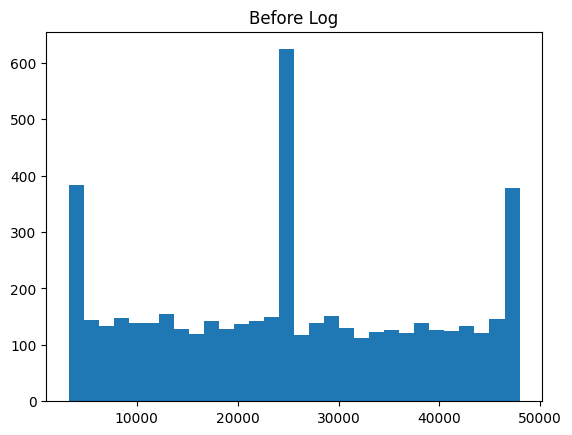

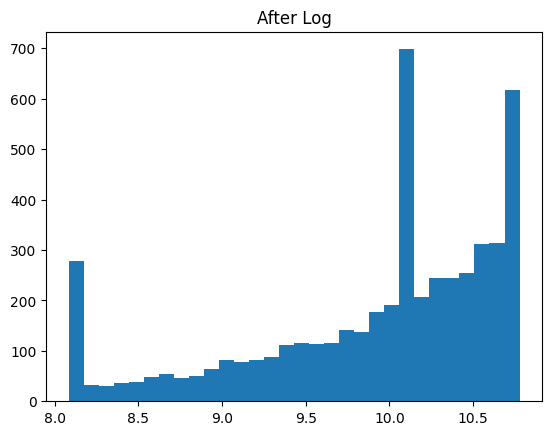

In [24]:

# - Compare before vs after distribution

import matplotlib.pyplot as plt

plt.hist(df['Treatment_Cost'], bins=30)
plt.title("Before Log")
plt.show()

plt.hist(df['Log_Treatment_Cost'], bins=30)
plt.title("After Log")
plt.show()


In [26]:
# Q9. Time-Based Missing Handling

# Scenario
# Admission dates should follow a logical sequence.

# Task:

# - Sort data by Admission_Date

df = df.sort_values(by='Admission_Date')

In [30]:
# - Apply forward fill or backward fill where appropriate

# Forward fill
df = df.ffill()


### - Justify your choice

- Justification for using Forward Fill

Forward fill (ffill) is appropriate because the dataset is sorted by Admission_Date, which follows a chronological order. In time-based data, missing values can often be logically inferred from the most recent previous observation. By using forward fill, we propagate the last known valid value forward, maintaining continuity and preserving the natural flow of the timeline.

This method is especially suitable in healthcare datasets where patient-related attributes (such as insurance coverage, hospital visits, or treatment-related fields) do not change abruptly within short time intervals. Therefore, using the previous known value is a reasonable and realistic assumption.